

```
# Clone repo, install deps, import folder to save files to
```

# SETUP Section

In [1]:

# ============================================================
# SECTION 0.1: Local Machine SETUP
# ============================================================
import sys
import os
from IPython.display import clear_output
# Verify installation
import gymnasium
import gymnasium_stag_hunt
print(f"Gymnasium version: {gymnasium.__version__}")
print(f"Stag Hunt installed successfully!")


os.makedirs('./content', exist_ok=True)
# Create project directory
PROJECT_DIR = './content'
os.makedirs(f'{PROJECT_DIR}/checkpoints_IDQN_noShaping', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs_IDQN_noShaping', exist_ok=True)

clear_output()
print(" setup complete!")
print(f" Project directory: {PROJECT_DIR}")

 setup complete!
 Project directory: ./content




# Import List


In [11]:
# ============================================================
# SECTION 1: IMPORTS & SEED SETTINGS
# ============================================================

# Standard library
import sys
import os
import time
import json
import pickle
from pathlib import Path
from collections import defaultdict
from typing import List, Dict, Tuple, Optional

from dataclasses import dataclass, field

# Data & visualization
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple
from collections import defaultdict
# Numpy and Tensorboard
import numpy as np
import time
from torch.utils.tensorboard import SummaryWriter
# Environment
import gymnasium
import gymnasium as gym
import gymnasium_stag_hunt
import torch
import torch.nn as nn
import torch.nn.functional as F
print("All imports successful!")

# Set device
DEVICE = torch.device("cpu")
torch.set_num_threads(4) #optional, depends on your machine

# Set random seeds for reproducibility
SEED = 456456 # Fixed seed for reproducibility either 123123 or 456456
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Using device: {DEVICE}")
print(f"Random seed: {SEED}")
print(f"PyTorch threads: {torch.get_num_threads()}")

All imports successful!
Using device: cpu
Random seed: 456456
PyTorch threads: 4



# Configuration parameters for everything

In [ ]:

@dataclass
class Config:
    """Central configuration for Stag Hunt MARL."""

    # ── Environment ────────────────────────────────────
    env_name: str = "StagHunt-Hunt-v0"
    obs_type: str = "coords"              # "coords" or "image"
    grid_size: Tuple[int, int] = (5, 5)   # Grid dimensions

    episodes_per_game: int = 500          # Max steps per episode 
    n_agents: int = 2

    # ── Environment rewards ────────────────────────────────────
    stag_reward: int = 5
    forage_reward: int = 1
    mauling_punishment: int = -5

    # ── Stag behavior and forage quantity ────────────────────────────────────
    stag_follows: bool = True             # Stag chases nearest agent
    run_away_after_maul: bool = False     # Stag stays after mauling
    forage_quantity: int = 2

    # ── Training ────────────────────────────────────────
    epochs: int = 1500                     # Total training epochs (500 is minimum for cooperation emergence - can increase to 2000+ for more stable results)
    batch_size: int = 3000                 # Batch size for learning updates (must be <= buffer_size - when buffer containes more than batch_size -> sampling starts)
    gamma: float = 0.99                    # Discount factor
    lr: float = 1e-4                       # Policy/value learning rate

    # ── buffer ────────────────────────────────────
    buffer_size: int = 10000              # Replay buffer size

    # ── epsilon ────────────────────────────────────
    epsilon_start:  float = 1.0    # must start high
    epsilon_end:    float = 0.05   # must end low
    epsilon_decay: float = 0.99999 
    target_update_interval: int = 2000
    
    # ── Network Architecture ────────────────────────────
    network_hidden: Tuple[int, ...] = (96, 96)   # 3 layers

    # ── Device ──────────────────────────────────────────
    device: str = "cpu"

    def __post_init__(self):
        """Validate and convert after initialization."""
        if self.device == "cuda" and not torch.cuda.is_available():
            print("CUDA not available, falling back to CPU")
            self.device = "cpu"


# Create config instance
cfg = Config()



# Neural Networks section


In [4]:

class agentNetwork(nn.Module):
  def __init__(self, obs_dim: int, act_dim: int, hidden_dims: List[int]):
        super().__init__()

        layers = [
            nn.Linear(obs_dim,        hidden_dims[0]), nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(),
            nn.Linear(hidden_dims[1], act_dim),
            # No activation at output : raw Q-values, not probabilities
        ]
        self.net = nn.Sequential(*layers)

  def forward(self, obs: torch.Tensor) -> torch.Tensor:
        """
        obs: (batch, obs_dim)
        returns: (batch, act_dim)  : one Q-value per action
        """
        return self.net(obs)



# IDQN shared buffer



In [5]:
class AgentSharedBuffer:
    """
    Shared experience replay buffer for all agents.
    Stores (obs, action, reward, next_obs, done) per agent per timestep.
    Samples a random mini-batch of B transitions.
    """

    def __init__(self, capacity: int, obs_dim: int, device: str = "cpu"):
        self.capacity = capacity
        self.device   = device
        self.ptr      = 0          # write cursor
        self.size     = 0          # current fill level

        # Pre-allocate fixed-size numpy arrays
        self.obs      = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions  = np.zeros((capacity,),         dtype=np.int64)
        self.rewards  = np.zeros((capacity,),         dtype=np.float32)
        self.dones    = np.zeros((capacity,),         dtype=bool)

    def add(self, obs: np.ndarray, action: int,
            reward: float, next_obs: np.ndarray, done: bool):
        """
        All transitions are stored identically.
        """
        self.obs[self.ptr]      = obs.astype(np.float32)
        self.next_obs[self.ptr] = next_obs.astype(np.float32)
        self.actions[self.ptr]  = action
        self.rewards[self.ptr]  = reward
        self.dones[self.ptr]    = done

        # Ring buffer: overwrite oldest when full
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int) -> dict:
        """
        Sample a random mini-batch of B transitions.
        Random indices drawn uniformly from whatever is currently stored.
        """
        idx = np.random.randint(0, self.size, size=batch_size)

        return {
            'obs':      torch.from_numpy(self.obs[idx]).to(self.device),
            'actions':  torch.from_numpy(self.actions[idx]).to(self.device),
            'rewards':  torch.from_numpy(self.rewards[idx]).to(self.device),
            'next_obs': torch.from_numpy(self.next_obs[idx]).to(self.device),
            'dones':    torch.from_numpy(self.dones[idx]).to(self.device),
        }

    def __len__(self):
        return self.size

# Agent implementation


In [ ]:


class IndependentAgent:
    """
    IDQN implementation: Agent owns a value network and a target network
    """
    def __init__(self, agent_id, obs_dim, act_dim, cfg):
        self.agent_id = agent_id
        self.act_dim  = act_dim
        self.cfg      = cfg
        self.device   = cfg.device

        self.value_net  = agentNetwork(obs_dim, act_dim, cfg.network_hidden).to(cfg.device)
        self.target_net = agentNetwork(obs_dim, act_dim, cfg.network_hidden).to(cfg.device)
        self.target_net.load_state_dict(self.value_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.value_net.parameters(), lr=cfg.lr)

    def _print_summary(self, act_dim, feature_dim):
        tar_params = sum(p.numel() for p in self.target_net.parameters())
        val_params = sum(p.numel() for p in self.value_net.parameters())
        print(f"   Agent architecture:")
        print(f"   Target net:    {tar_params:,} params ({feature_dim} → {act_dim})")
        print(f"   Value net:     {val_params:,} params ({feature_dim} → 1)")
        print(f"   Total per agent: {tar_params + val_params:,}")

    # ── Action selection ────────────────────────────────────

    def act(self, obs: np.ndarray, epsilon: float = 0.0) -> int:
        if np.random.rand() < epsilon:
            return np.random.randint(self.act_dim)
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.value_net(obs_t)   # (1, act_dim)
        return q_values.argmax(dim=-1).item()

 # ── Shared replay: called by the training loop ───────────
    def update(self, batch):
        # Correctly extract tensors from the batch dictionary
        obs      = batch['obs']
        act      = batch['actions']
        rew      = batch['rewards']
        next_obs = batch['next_obs']
        done     = batch['dones']

        with torch.no_grad():
            q_next = self.target_net(next_obs).max(dim=-1).values
            td_target = rew + self.cfg.gamma * q_next * (~done).float()

        q_pred = self.value_net(obs).gather(
            1, act.unsqueeze(1)).squeeze(1)

        loss = F.mse_loss(q_pred, td_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

    # ── Hard-copy value_net → target_net every N steps ───────
    def sync_target(self):
        self.target_net.load_state_dict(self.value_net.state_dict())

    
    # ── SAVE / LOAD ───────────
    
    def save(self, path):
        torch.save({
            'target': self.target_net.state_dict(),
            'value': self.value_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
        }, path)

    def load(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.target_net.load_state_dict(checkpoint['target'])
        self.value_net.load_state_dict(checkpoint['value'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])


print("IndependentAgent ready!")

IndependentAgent ready!


# Training loop declaration

In [ ]:

class Trainer:
    """Collects experience separately for each agent and updates independently."""

    def __init__(self, env, agents, shared_buffer, cfg):
        self.env = env
        self.agents = agents
        self.cfg = cfg
        self.shared_buffer = shared_buffer
        self.metrics = defaultdict(list)
        self.writer = SummaryWriter("runs/staghunt")

    def train_one_epoch(self, t: int, obs: np.ndarray, epsilon: float):
        actions = [
            agent.act(obs[i], epsilon)
            for i, agent in enumerate(self.agents)
        ]

        next_obs, rewards, terminated, truncated, _ = self.env.step(actions)
        done = terminated or truncated
        
        # Optional reward shaping based on distance to stag (not used in final version) can mitigate std reward variance
        # Compare next_obs distance beewteen agents and stag
        # If agents closer reinforce behaviour and reinforce more if when they get closer stag gets closer
        # if(obs[0][10] < next_obs[0][10]):
        #     rewards += (1,1)
        #     if(obs[1][11] < next_obs[1][11]):
        #         rewards += (1,1)
            
        # Store transition in shared buffer
        for i, agent in enumerate(self.agents):
            self.shared_buffer.add(obs[i], actions[i], rewards[i], next_obs[i], done)

        losses = {}

        # Update agents if enough data in buffer
        if len(self.shared_buffer) >= self.cfg.batch_size:
            batch = self.shared_buffer.sample(self.cfg.batch_size)

            for agent in self.agents:
                losses[agent.agent_id] = agent.update(batch)

            # Sync target networks at specified intervals
            if t % self.cfg.target_update_interval == 0:
                for agent in self.agents:
                    agent.sync_target()

        return next_obs, done, losses, rewards 

    def train(self):
        print(f"\n Training for {self.cfg.epochs} episodes")
        print(f"   Steps/episode: {self.cfg.episodes_per_game}")
        print(f"   Total steps:   {self.cfg.epochs * self.cfg.episodes_per_game:,}")
        print(f"   {'─' * 50}")

        start_time = time.time()
        epsilon = self.cfg.epsilon_start
        all_losses = defaultdict(list)
        global_t = 0

        for episode in range(self.cfg.epochs):
            obs, _ = self.env.reset()
            ep_return = 0.0
            ep_losses = defaultdict(list)

            for t in range(self.cfg.episodes_per_game):
                next_obs, done, losses, rewards = self.train_one_epoch(global_t, obs, epsilon)

                ep_return += sum(rewards)          

                for aid, loss in losses.items():
                    ep_losses[aid].append(loss)
                    all_losses[aid].append(loss)

                epsilon = max(self.cfg.epsilon_end, epsilon * self.cfg.epsilon_decay)
                global_t += 1
                obs = next_obs

                if done:
                    break

    # ─────────── Logging and metrics ────────────────────────────────────
            
            self.metrics['ep_return'].append(ep_return)
            for aid, v in ep_losses.items():
                self.metrics[f'loss_agent_{aid}'].append(
                    np.mean(v) if v else float('nan')
                )
            self.writer.add_scalar("Return/episode", ep_return, episode)
            self.writer.add_scalar("Epsilon", epsilon, episode)
            for aid, v in ep_losses.items():
                if v:
                    self.writer.add_scalar(f"Loss/agent_{aid}", np.mean(v), episode)
            if episode % 10 == 0 or episode == self.cfg.epochs - 1:
                avg_loss = {
                    aid: np.mean(v) if v else float('nan')
                    for aid, v in ep_losses.items()
                }
                loss_str = " | ".join(f"A{aid} L:{l:.4f}" for aid, l in avg_loss.items())
                elapsed  = time.time() - start_time
                print(
                    f"Ep {episode:4d}/{self.cfg.epochs} | "
                    f"ε={epsilon:.3f} | {loss_str} | "
                    f"Return: {ep_return:7.1f} | "
                    f"Buffer: {len(self.shared_buffer):5d} | "
                    f"t={global_t:7,d} | "
                    f"Elapsed: {elapsed:.1f}s"
                )
        print(f"\n Done! ...")
        self.writer.close()
        print(f"\n Done! Total steps: {global_t:,} | "
              f"Time: {(time.time() - start_time)/60:.1f} min")

    def evaluate(self, num_episodes=100):
        total_rewards = []
        coop_steps = 0
        total_steps = 0

        for ep in range(num_episodes):
            obs, _ = self.env.reset()
            done = False
            ep_reward = 0

            while not done:
                actions = [agent.act(obs[i], epsilon=0.0)
                           for i, agent in enumerate(self.agents)]
                obs, rewards, terminated, truncated, _ = self.env.step(actions)
                done = terminated or truncated

                ep_reward  += sum(rewards)
                total_steps += 1

               
                if rewards[0] == self.cfg.stag_reward and \
                   rewards[1] == self.cfg.stag_reward:
                    coop_steps += 1

            total_rewards.append(ep_reward)

        avg_reward = np.mean(total_rewards)
        coop_rate  = coop_steps / total_steps * 100 if total_steps > 0 else 0

        print(f"\n Evaluation ({num_episodes} episodes):")
        print(f"   Average Reward:   {avg_reward:.1f} ± {np.std(total_rewards):.1f}")
        print(f"   Cooperation Rate: {coop_rate:.1f}%")

        return {
            'avg_reward':       avg_reward,
            'cooperation_rate': coop_rate,
            'total_rewards':    total_rewards
        }

    def plot_training_curves(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Plot 1: Episode Return
        if 'ep_return' in self.metrics:
            returns = self.metrics['ep_return']
            axes[0].plot(returns, alpha=0.4, color='steelblue', label='raw')
            # smoothed
            if len(returns) >= 10:
                smoothed = np.convolve(returns, np.ones(10)/10, mode='valid')
                axes[0].plot(smoothed, color='steelblue', linewidth=2, label='avg10')
            axes[0].set_xlabel('Episode')
            axes[0].set_ylabel('Episode Return')
            axes[0].set_title('Training Returns')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

        colors = ['tomato', 'seagreen']
        for aid, color in zip(range(len(self.agents)), colors):
            key = f'loss_agent_{aid}'
            if key in self.metrics:
                v = self.metrics[key]
                axes[1].plot(v, alpha=0.4, color=color, label=f'A{aid} raw')
                if len(v) >= 10:
                    smoothed = np.convolve(v, np.ones(10)/10, mode='valid')
                    axes[1].plot(smoothed, color=color, linewidth=2, label=f'A{aid} avg10')

        axes[1].set_xlabel('Episode')
        axes[1].set_ylabel('TD Loss')
        axes[1].set_title('Agent Losses')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


print(" Trainer ready!")

 Trainer ready!


# MAIN - entry point

In [14]:


class DistanceAugmentedObs(gym.Wrapper):
    """
    Appends 2 extra scalars to each agent's obs vector:
      - dist_agents  : Euclidean distance between the two agents
      - dist_self_stag: Euclidean distance from this agent to the stag
    New obs shape: (2, 12)
    """

    def __init__(self, env):
        super().__init__(env)
        orig_shape = env.observation_space.shape  # (2, 10)
        n_agents, obs_len = orig_shape            # 2, 10

        self.observation_space = gym.spaces.Box(
            low=0,
            high=np.inf,
            shape=(n_agents, obs_len + 2),        # (2, 12)
            dtype=np.float32,
        )

    @staticmethod
    def _augment(obs: np.ndarray) -> np.ndarray:
        """
        obs: (2, 10) int/float array
        returns: (2, 12) float array
        """
        obs = obs.astype(np.float32)

        # Agent 0 coords (from its own row)  →  obs[0, 0:2]
        # Agent 1 coords (from its own row)  →  obs[1, 0:2]
        a0 = obs[0, 0:2]   # agent 0 self-position
        a1 = obs[1, 0:2]   # agent 1 self-position

        # Stag coords are at indices 4:6 in both rows (same stag)
        s0 = obs[0, 4:6]   # stag as seen by agent 0
        s1 = obs[1, 4:6]   # stag as seen by agent 1

        dist_agents   = np.linalg.norm(a0 - a1)          # scalar, same for both
        dist_a0_stag  = np.linalg.norm(a0 - s0)
        dist_a1_stag  = np.linalg.norm(a1 - s1)
        # Append per-agent features
        row0 = np.append(obs[0], [dist_agents, dist_a0_stag])
        row1 = np.append(obs[1], [dist_agents, dist_a1_stag])

        return np.stack([row0, row1], axis=0)             # (2, 12)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._augment(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._augment(obs), reward, terminated, truncated, info


In [15]:

# ─────────── Main Section ───────────────────────────────────────────────────────────────

# ── Environment ──────────────────────────────────────────────
base_env = gymnasium.make(
    cfg.env_name,
    enable_multiagent=True,
    obs_type=cfg.obs_type,
    grid_size=cfg.grid_size,
    stag_follows=cfg.stag_follows,
    run_away_after_maul=cfg.run_away_after_maul,
    max_timesteps=cfg.episodes_per_game
)

# Wrap with custom observation wrapper to add distance features
env = DistanceAugmentedObs(base_env)

obs, _ = env.reset()
obs_dim    = env.observation_space.shape[1]
act_dim    = env.action_space.n
num_agents = env.observation_space.shape[0]

print(f"Env:        {cfg.env_name}")
print(f"obs_dim:    {obs_dim}  |  act_dim: {act_dim}  |  agents: {num_agents}")
print(f"obs shape:  {obs.shape}  range: [{obs.min()}, {obs.max()}]")

# ── Agents ────────────────────
agents = [
    IndependentAgent(i, obs_dim, act_dim, cfg)
    for i in range(num_agents)
]

# ── Shared replay buffer (line 3: single Dshared for all agents) ──────────────
# Buffer instantiated here and passed explicitly to Trainer
shared_buffer = AgentSharedBuffer(
    capacity = cfg.buffer_size,
    obs_dim  = obs_dim,
    device   = cfg.device
)

print(f"\nBuffer capacity: {cfg.buffer_size:,} transitions")
print(f"Starts updating after {cfg.batch_size} transitions collected")

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(env, agents, shared_buffer, cfg)
trainer.train()
trainer.evaluate() # optiona return array of rewards with average reward and cooperation rate

Env:        StagHunt-Hunt-v0
obs_dim:    12  |  act_dim: 5  |  agents: 2
obs shape:  (2, 12)  range: [0.0, 4.0]

Buffer capacity: 10,000 transitions
Starts updating after 3000 transitions collected

🚀 Training for 500 episodes
   Steps/episode: 500
   Total steps:   250,000
   ──────────────────────────────────────────────────
Ep    0/500 | ε=0.995 |  | Return:  -795.0 | Buffer:  1000 | t=    500 | Elapsed: 0.0s
Ep   10/500 | ε=0.946 | A0 L:1.4578 | A1 L:1.4602 | Return:  -758.0 | Buffer: 10000 | t=  5,500 | Elapsed: 25.3s
Ep   20/500 | ε=0.900 | A0 L:0.8049 | A1 L:0.8395 | Return:  -729.0 | Buffer: 10000 | t= 10,500 | Elapsed: 64.0s
Ep   30/500 | ε=0.856 | A0 L:0.8170 | A1 L:0.8473 | Return:  -733.0 | Buffer: 10000 | t= 15,500 | Elapsed: 103.8s
Ep   40/500 | ε=0.815 | A0 L:0.8724 | A1 L:0.9139 | Return:  -509.0 | Buffer: 10000 | t= 20,500 | Elapsed: 135.7s
Ep   50/500 | ε=0.775 | A0 L:1.0937 | A1 L:1.0923 | Return:  -601.0 | Buffer: 10000 | t= 25,500 | Elapsed: 166.6s
Ep   60/500 | ε=

{'avg_reward': np.float64(894.37),
 'cooperation_rate': 19.434,
 'total_rewards': [1150.0,
  -3.0,
  1185.0,
  1290.0,
  1190.0,
  1131.0,
  1191.0,
  -4.0,
  1160.0,
  1226.0,
  1245.0,
  1.0,
  1186.0,
  1216.0,
  1230.0,
  1141.0,
  1185.0,
  0.0,
  1181.0,
  0.0,
  1187.0,
  1186.0,
  1150.0,
  1196.0,
  -4.0,
  1345.0,
  1215.0,
  1210.0,
  1176.0,
  1245.0,
  1200.0,
  1135.0,
  1225.0,
  1250.0,
  1125.0,
  1230.0,
  1191.0,
  1265.0,
  1140.0,
  -4.0,
  1190.0,
  1211.0,
  1186.0,
  1170.0,
  1182.0,
  80.0,
  1211.0,
  1221.0,
  -5.0,
  1305.0,
  0.0,
  1080.0,
  1266.0,
  1136.0,
  1101.0,
  1070.0,
  1163.0,
  1165.0,
  1251.0,
  -2465.0,
  1170.0,
  -2474.0,
  1245.0,
  1157.0,
  1140.0,
  1250.0,
  1275.0,
  1240.0,
  1236.0,
  1285.0,
  1157.0,
  1200.0,
  -5.0,
  0.0,
  -3.0,
  1196.0,
  1136.0,
  1221.0,
  1170.0,
  1195.0,
  1205.0,
  1180.0,
  1161.0,
  1169.0,
  1130.0,
  1297.0,
  1220.0,
  1200.0,
  0.0,
  1110.0,
  1160.0,
  1131.0,
  -2465.0,
  1286.0,
  1206.0,


# Evaluation Section


 Evaluation (100 episodes):
   Avg Reward: 875.3 ± 853.2
   Cooperation: 20.0%
   Max: 1371, Min: -2473


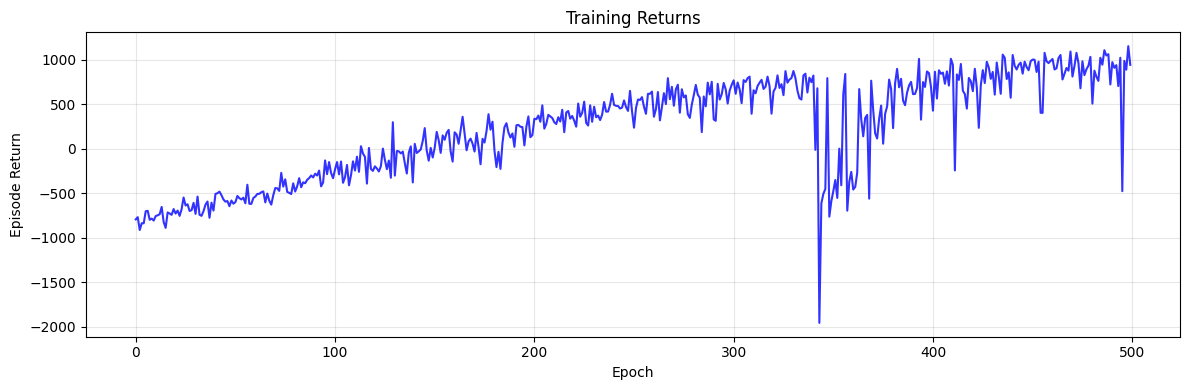

In [27]:
# ─────────── Simple plot for training metrics ───────────

def evaluate(env, agents, num_episodes=100):
    """Simple, clean evaluation."""
    total_rewards = []
    coop_count = 0
    total_steps = 0

    for ep in range(num_episodes):
        obs, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            # Each agent acts independently
            actions = [agent.act(obs[i]) for i, agent in enumerate(agents)]
            obs, rewards, terminated, truncated, _ = env.step(actions)
            done = terminated or truncated

            ep_reward += sum(rewards)
            total_steps += 1

            # Count cooperation (both get stag reward)
            if rewards[0] == 5 and rewards[1] == 5:
                coop_count += 1

        total_rewards.append(ep_reward)

    avg_reward = np.mean(total_rewards)
    coop_rate = (coop_count / total_steps * 100) if total_steps > 0 else 0

    print(f"\n Evaluation ({num_episodes} episodes):")
    print(f"   Avg Reward: {avg_reward:.1f} ± {np.std(total_rewards):.1f}")
    print(f"   Cooperation: {coop_rate:.1f}%")
    print(f"   Max: {np.max(total_rewards):.0f}, Min: {np.min(total_rewards):.0f}")

    return {
        'avg_reward': avg_reward,
        'cooperation_rate': coop_rate,
        'total_rewards': total_rewards,
    }


def plot_training_curves(trainer):
    """Plot training metrics from trainer.metrics."""
    fig, axes = plt.subplots(figsize=(12, 4))

    # Plot 1: Episode Return
    if 'ep_return' in trainer.metrics:
        returns = trainer.metrics['ep_return']
        axes.plot(returns, 'b-', alpha=0.8)
        axes.set_xlabel('Epoch')
        axes.set_ylabel('Episode Return')
        axes.set_title('Training Returns')
        axes.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# RUN EVALUATION
results = evaluate(env, agents, num_episodes=100)
plot_training_curves(trainer)

In [29]:
# ─────────── Agent Behaviours and Reward Analysis ────────────────────────────────────

def diagnose(env, agents, cfg, num_episodes=20):
    """Look inside agent behavior — what actions are they taking?"""

    action_names = {0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT', 4: 'STAY'}  

    action_counts  = [defaultdict(int) for _ in agents]
    reward_types   = defaultdict(int)  # track what rewards are actually given
    joint_actions  = defaultdict(int)  # track action pairs

    for ep in range(num_episodes):
        obs, _ = env.reset()
        done = False

        while not done:
            actions = [agents[i].act(obs[i]) for i in range(len(agents))]
            obs, rewards, terminated, truncated, _ = env.step(actions)
            done = terminated or truncated

            # Track each agent's action distribution
            for i, a in enumerate(actions):
                action_counts[i][a] += 1

            # Track joint action pairs
            joint_actions[tuple(actions)] += 1

            # Classify reward signal
            r0, r1 = rewards[0], rewards[1]
            if r0 == cfg.stag_reward and r1 == cfg.stag_reward:
                reward_types['STAG_COOP'] += 1
            elif r0 == cfg.forage_reward or r1 == cfg.forage_reward:
                reward_types['FORAGE'] += 1
            elif r0 == cfg.mauling_punishment or r1 == cfg.mauling_punishment:
                reward_types['MAUL'] += 1
            else:
                reward_types[f'OTHER({r0},{r1})'] += 1

    total_steps = sum(reward_types.values())

    # ── Action distributions ─────────────────────────────
    print("=" * 55)
    print("ACTION DISTRIBUTIONS")
    print("=" * 55)
    for i, counts in enumerate(action_counts):
        total = sum(counts.values())
        print(f"\nAgent {i}:")
        for a in sorted(counts):
            name = action_names.get(a, f'ACT_{a}')
            pct  = counts[a] / total * 100
            bar  = '█' * int(pct / 2)
            print(f"  {name:6s} [{a}]: {bar:<25} {pct:.1f}%")

    # ── Reward breakdown ─────────────────────────────────
    print("\n" + "=" * 55)
    print("REWARD BREAKDOWN")
    print("=" * 55)
    for rtype, count in sorted(reward_types.items(), key=lambda x: -x[1]):
        pct = count / total_steps * 100
        print(f"  {rtype:<20}: {count:5d} steps ({pct:.1f}%)")

    # ── Most common joint actions ────────────────────────
    print("\n" + "=" * 55)
    print("TOP 10 JOINT ACTION PAIRS (agent0, agent1)")
    print("=" * 55)
    for pair, count in sorted(joint_actions.items(), key=lambda x: -x[1])[:10]:
        pct  = count / total_steps * 100
        a0   = action_names.get(pair[0], str(pair[0]))
        a1   = action_names.get(pair[1], str(pair[1]))
        print(f"  ({a0:5s}, {a1:5s}): {count:5d} steps ({pct:.1f}%)")

    # ── Coordination score ───────────────────────────────
    same_action = sum(v for k, v in joint_actions.items() if k[0] == k[1])
    print(f"\n  Same action both agents: {same_action/total_steps*100:.1f}% of steps")
    print(f"  Forage dominance:        {reward_types['FORAGE']/total_steps*100:.1f}% of steps")


diagnose(env, agents, cfg, num_episodes=20)

ACTION DISTRIBUTIONS

Agent 0:
  UP     [0]: █                         3.3%
  DOWN   [1]: ██████                    13.3%
  LEFT   [2]: ██████████████            29.1%
  RIGHT  [3]: ████████                  17.1%
  STAY   [4]: ██████████████████        37.2%

Agent 1:
  UP     [0]:                           1.3%
  DOWN   [1]: ████████                  16.9%
  LEFT   [2]: █████████████             26.8%
  RIGHT  [3]: ████████                  18.0%
  STAY   [4]: ██████████████████        37.0%

REWARD BREAKDOWN
  OTHER(0.0,0.0)      :  7581 steps (75.8%)
  STAG_COOP           :  1903 steps (19.0%)
  MAUL                :   506 steps (5.1%)
  FORAGE              :    10 steps (0.1%)

TOP 10 JOINT ACTION PAIRS (agent0, agent1)
  (STAY , STAY ):  1939 steps (19.4%)
  (LEFT , LEFT ):  1206 steps (12.1%)
  (LEFT , STAY ):  1106 steps (11.1%)
  (STAY , LEFT ):   993 steps (9.9%)
  (DOWN , DOWN ):   823 steps (8.2%)
  (STAY , RIGHT):   580 steps (5.8%)
  (RIGHT, LEFT ):   473 steps (4.7%)
  (

# Save the model




In [31]:
# ─────────── Save Model and Metrics ───────────────────────────────────────────────────────────────

# Save models
for i, agent in enumerate(agents):
    save_path = f"{PROJECT_DIR}/checkpoints_IDQN_noShaping/agent_{i}_Multiagent_noShaping.pt"
    agent.save(save_path)
    print(f" Saved Agent {i} to {save_path}")

# Save configuration
import json
with open(f"{PROJECT_DIR}/config.json", 'w') as f:
    json.dump(cfg.__dict__, f, indent=2, default=str)
print(f" Saved configuration")

# Save metrics
import pickle
with open(f"{PROJECT_DIR}/training_metrics.pkl", 'wb') as f:
    pickle.dump(trainer.metrics, f)
print(f" Saved training metrics")

print(f"\n All results saved to {PROJECT_DIR}")

 Saved Agent 0 to ./content/checkpoints_IDQN_noShaping/agent_0_Multiagent_noShaping.pt
 Saved Agent 1 to ./content/checkpoints_IDQN_noShaping/agent_1_Multiagent_noShaping.pt
 Saved configuration
 Saved training metrics

 All results saved to ./content


# Watch The Agents play

In [ ]:
def setup_environment_and_agents_for_play(cfg, checkpoint_paths, render_mode="human"):
    """
    Create environment with rendering enabled and load trained agents.
    """
    # Create environment
    base_env = gymnasium.make(cfg.env_name, enable_multiagent=True, obs_type=cfg.obs_type, grid_size=cfg.grid_size, stag_reward=cfg.stag_reward, forage_reward=cfg.forage_reward, mauling_punishment=cfg.mauling_punishment, stag_follows=cfg.stag_follows, run_away_after_maul=cfg.run_away_after_maul)
    env = DistanceAugmentedObs(base_env)

    # Manually set render_mode attribute (required by the environment for rendering)
    env.unwrapped.render_mode = render_mode

    obs, _ = env.reset()
    obs_dim = env.observation_space.shape[1]
    act_dim = env.action_space.n
    num_agents = env.observation_space.shape[0]

    # Create agent objects
    agents = [
        IndependentAgent(i, obs_dim, act_dim, cfg)
        for i in range(num_agents)
    ]

    # Load saved weights using the agent's load() method
    for i, path in enumerate(checkpoint_paths):
        if os.path.exists(path):
            print(f" Loading agent {i} weights from: {path}")
            agents[i].load(path)
        else:
            print(f"  Checkpoint not found for agent {i}: {path}")
            print(f"   Agent {i} will act randomly (no saved weights).")

    return env, agents, obs_dim, act_dim


def watch_agents(env, agents, cfg, num_episodes=1, epsilon=0.0, delay=0.1):
    """
    Run episodes with rendering enabled and print per-step actions/rewards.
    """
    for ep in range(1, num_episodes + 1):
        print(f"\n{'='*40}")
        print(f" Episode {ep}")
        print(f"{'='*40}")
        obs, _ = env.reset()
        done = False
        ep_rewards = [0.0 for _ in agents]
        step = 0

        while not done:
            # Render the environment (uses env.render_mode)
            env.render()

            # Each agent selects an action
            actions = []
            for i, agent in enumerate(agents):
                action = agent.act(obs[i], epsilon=epsilon)
                actions.append(action)
                action_name = "Hunt" if action == 0 else "Forage"
                print(f"Step {step:3d} | Agent {i} → {action_name}")

            # Step environment
            next_obs, rewards, terminated, truncated, info = env.step(actions)
            done = terminated or truncated
            obs = next_obs
            step += 1

            for i, r in enumerate(rewards):
                ep_rewards[i] += r
                print(f"         Reward Agent {i}: {r:+5.1f} (total {ep_rewards[i]:.1f})")

            if delay > 0:
                time.sleep(delay)

        # End of episode
        print(f"\n Episode {ep} finished")
        print(f"   Joint reward: {sum(ep_rewards):.1f}")
        for i, r in enumerate(ep_rewards):
            print(f"   Agent {i} total: {r:.1f}")
        print(f"   Steps: {step}")

    env.close()
    print("\n Done watching.")

# save the agents weights in oreder to load them, Check correctness of the path. The first section of the notebook handles the creation of the content dir and its subdirs
setup_environment_and_agents_for_play(cfg, [f"./content/checkpoints_IDQN_noShaping/agent_{i}_Multiagent_noShaping.pt" for i in range(num_agents)], render_mode="human")
watch_agents(env, agents, cfg, num_episodes=3, epsilon=0.0, delay=0.5)

 Loading agent 0 weights from: ./content/checkpoints_IDQN_noShaping/agent_0_Multiagent_noShaping.pt
 Loading agent 1 weights from: ./content/checkpoints_IDQN_noShaping/agent_1_Multiagent_noShaping.pt

 Episode 1
╔════════════════════════════╗
║ ·A   ·    ·    ·    ·    · ║
║ ·    ·    ·    ·    ·    · ║
║ ·    ·    ·  S ·    ·   P· ║
║ ·    ·    ·    ·    ·    · ║
║ · B  ·    ·    ·   P·    · ║
╚════════════════════════════╝
Step   0 | Agent 0 → Forage
Step   0 | Agent 1 → Forage
         Reward Agent 0:  +0.0 (total 0.0)
         Reward Agent 1:  +0.0 (total 0.0)
╔════════════════════════════╗
║ ·    ·    ·    ·    ·    · ║
║ ·A   ·    ·    ·    ·    · ║
║ ·    ·  S ·    ·    ·   P· ║
║ ·    ·    ·    ·    ·    · ║
║ · B  ·    ·    ·   P·    · ║
╚════════════════════════════╝
Step   1 | Agent 0 → Forage
Step   1 | Agent 1 → Forage
         Reward Agent 0:  +0.0 (total 0.0)
         Reward Agent 1:  +0.0 (total 0.0)
╔════════════════════════════╗
║ ·    ·    ·    ·    ·    · ║
║ ·    ·

KeyboardInterrupt: 